# Proyecto #2
## Semana 1: Análisis Exploratorio de Datos (EDA)

---

## 1. Importación de Librerías y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
colors = {'Benigno': '#2ecc71', 'Maligno': '#e74c3c'}

In [6]:
#dataset
df = pd.read_csv('Datos.csv')
print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head(10)

Dimensiones del dataset: 683 filas × 11 columnas


,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


## 2. Conjunto data

El dataset contiene 682 registros de biopsias de aspiración con aguja fina (FNA) de masas mamarias. De lo identificado por el grupoo, se comprendió que se tiene 9 características de 1 a 10, más una variable de clase (2 = Benigno, 4 = Maligno)

In [7]:
print("=*"*60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=*"*60)
print(f"N de muestras: {df.shape[0]}")
print(f"N de variables: {df.shape[1]}")
print(f"\n--- Tipos de datos ---")
print(df.dtypes)
print(f"\n--- Valores nulos por columna ---")
print(df.isnull().sum())
print(f"\nTotal de valores nulos: {df.isnull().sum().sum()}")

=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
INFORMACIÓN GENERAL DEL DATASET
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
N de muestras: 683
N de variables: 11

--- Tipos de datos ---
Sample code number             int64
Clump Thickness                int64
Uniformity of Cell Size        int64
Uniformity of Cell Shape       int64
Marginal Adhesion              int64
Single Epithelial Cell Size    int64
Bare Nuclei                    int64
Bland Chromatin                int64
Normal Nucleoli                int64
Mitoses                        int64
Class                          int64
dtype: object

--- Valores nulos por columna ---
Sample code number             0
Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nucle

In [8]:
df.describe().round(2)

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,683.00,683.00,683.00,683.00,683.00,683.00,683.00,683.00,683.00,683.00,683.00
mean,1076720.23,4.44,3.15,3.22,2.83,3.23,3.54,3.45,2.87,1.60,2.70
std,620644.05,2.82,3.07,2.99,2.86,2.22,3.64,2.45,3.05,1.73,0.95
min,63375.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00
25%,877617.00,2.00,1.00,1.00,1.00,2.00,1.00,2.00,1.00,1.00,2.00
50%,1171795.00,4.00,1.00,1.00,1.00,2.00,1.00,3.00,1.00,1.00,2.00
75%,1238705.00,6.00,5.00,5.00,4.00,4.00,6.00,5.00,4.00,1.00,4.00
max,13454352.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,4.00


**Interpretación:** No hay valores nulos. Todas las variables son numéricas enteras con rango de 1 a 10 (excepto el ID y la clase). Ahora, con el equipo detectamos que la variable `Sample code number` es un identificador. La catallogamos como identificador porque no aporta información predictiva. ¡Atención! La excluimos del análisis

## 3. Análisis de la Variable Objetivo

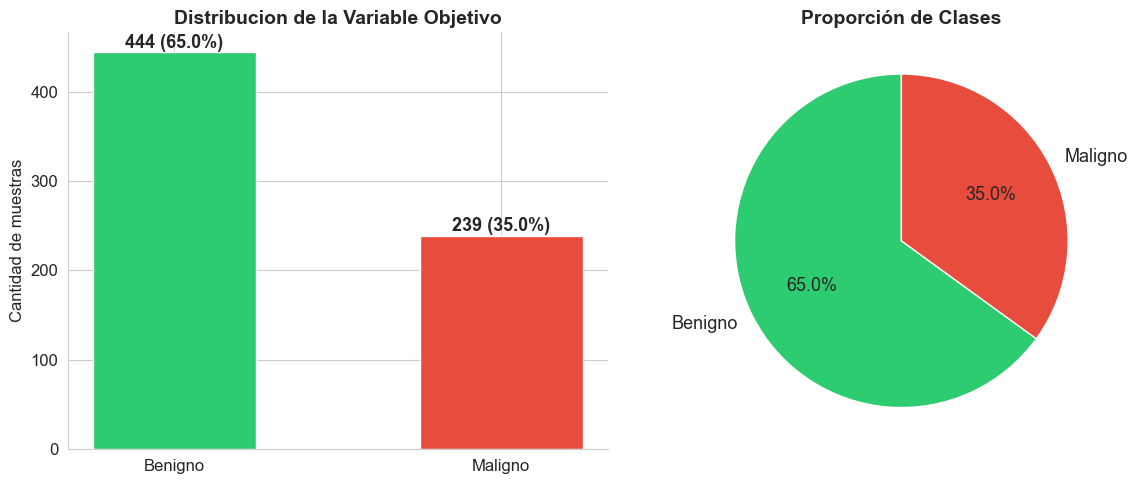


Clase mayoritaria: Benigno (444 muestras, 65.0%)
Clase minoritaria: Maligno (239 muestras, 35.0%)
Ratio de desbalance: 1.86:1


In [9]:
#Prep variable de clase legible
df['Diagnostico'] = df['Class'].map({2: 'Benigno', 4: 'Maligno'})

#distribucion de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#graph de barras
counts = df['Diagnostico'].value_counts()
bars = axes[0].bar(counts.index, counts.values, 
                   color=[colors[c] for c in counts.index], 
                   edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    pct = val/len(df)*100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 f'{val} ({pct:.1f}%)', ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Distribucion de la Variable Objetivo', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cantidad de muestras')
axes[0].spines[['top','right']].set_visible(False)

#graph de pastel
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[colors[c] for c in counts.index], startangle=90,
            textprops={'fontsize': 13})
axes[1].set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nClase mayoritaria: Benigno ({counts['Benigno']} muestras, {counts['Benigno']/len(df)*100:.1f}%)")
print(f"Clase minoritaria: Maligno ({counts['Maligno']} muestras, {counts['Maligno']/len(df)*100:.1f}%)")
print(f"Ratio de desbalance: {counts['Benigno']/counts['Maligno']:.2f}:1")

**Interpretación:** Existe un desbalance moderado (1.86:1) a favor de la clase benigna. Esto significa que un clasificador que prediga siempre "benigno" tendría un 65% de exactitud. Esto es importante. Por tanto, métricas como Precision, Recall y F1-Score serán más informativas que la accuracy sola. Nosotros identidicamos que el Recall de la clase maligna es especialmente de importancia, ya que un falso negativo implica no detectar un cáncer

## 4. Distribución de Características por Clase

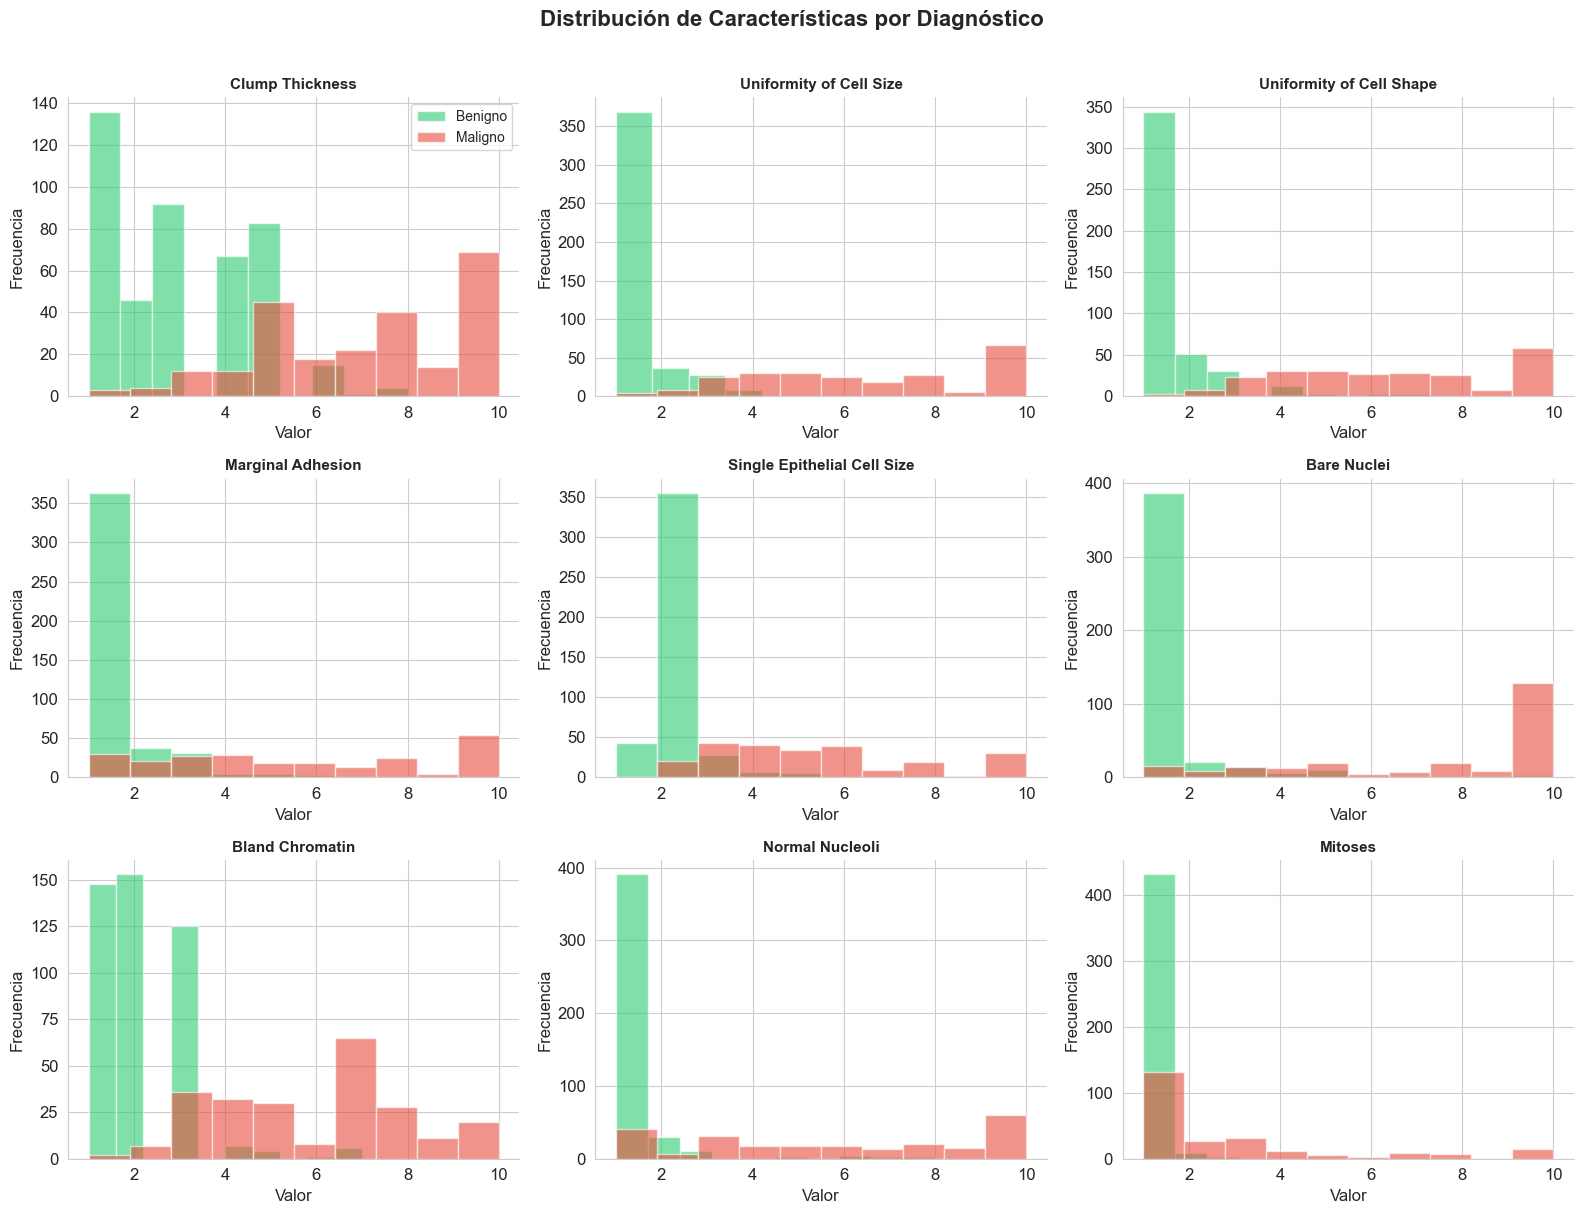

In [10]:
# Variables predictoras (minus ID y clase)
feat_cols = [c for c in df.columns if c not in ['Sample code number', 'Class', 'Diagnostico']]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(feat_cols):
    ax = axes[i]
    for label, color in colors.items():
        subset = df[df['Diagnostico'] == label][col]
        ax.hist(subset, bins=10, alpha=0.6, color=color, label=label, edgecolor='white')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.spines[['top','right']].set_visible(False)

axes[0].legend(fontsize=10)
fig.suptitle('Distribución de Características por Diagnóstico', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación:** Se observa una clara separación entre las distribuciones de ambas clases en la mayoría de las variables. Las muestras benignas se concentran en valores bajos (1-3), mientras que las malignas muestran distribuciones más dispersas con valores altos. Las variables con mayor poder discriminativo visual son Uniformity of Cell Size, Uniformity of Cell Shape y Bare Nuclei. La variable Mitoses es la menos discriminativa, con la mayoría de valores concentrados en 1 para ambas clases.

## 5. Análisis de Correlaciones

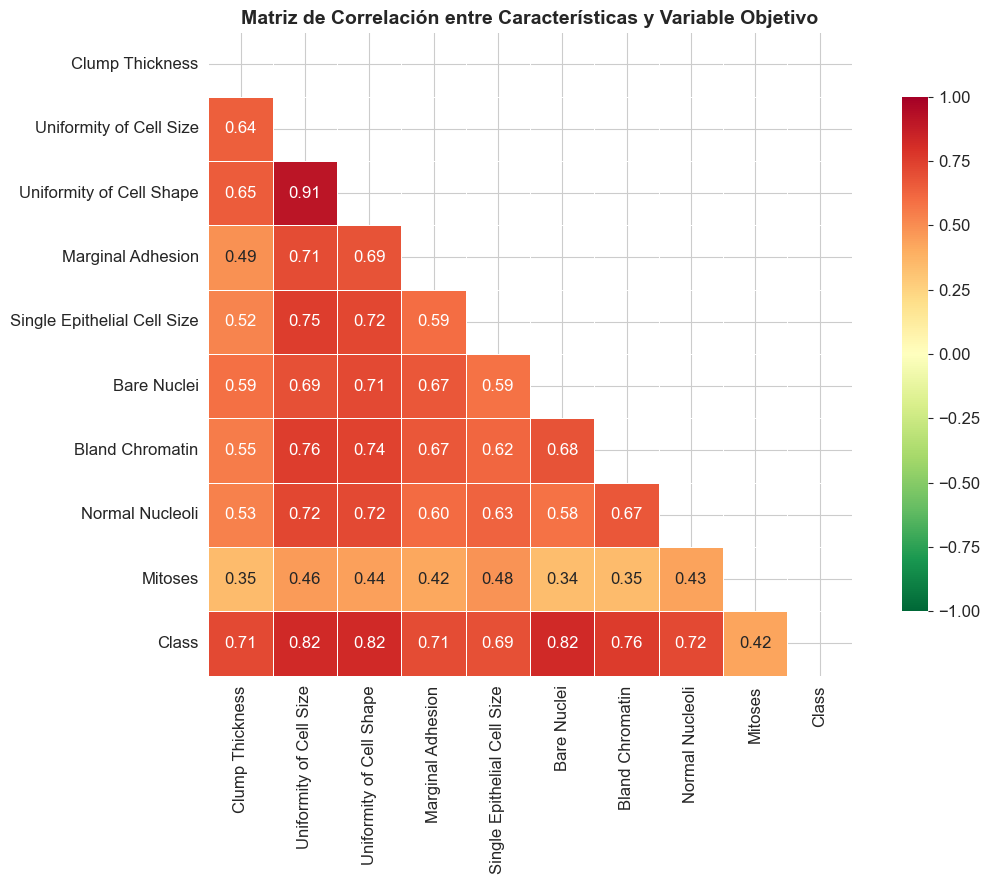


CORRELACIONES CON LA VARIABLE OBJETIVO (Class)
Bare Nuclei                    r = 0.823  ████████████████
Uniformity of Cell Shape       r = 0.822  ████████████████
Uniformity of Cell Size        r = 0.821  ████████████████
Bland Chromatin                r = 0.758  ███████████████
Normal Nucleoli                r = 0.719  ██████████████
Clump Thickness                r = 0.715  ██████████████
Marginal Adhesion              r = 0.706  ██████████████
Single Epithelial Cell Size    r = 0.691  █████████████
Mitoses                        r = 0.423  ████████


In [11]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df[feat_cols + ['Class']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación entre Características y Variable Objetivo', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("CORRELACIONES CON LA VARIABLE OBJETIVO (Class)")
print("="*50)
corr_class = corr['Class'].drop('Class').sort_values(ascending=False)
for var, val in corr_class.items():
    bar = '█' * int(abs(val) * 20)
    print(f"{var:30s} r = {val:.3f}  {bar}")

**Interpretación:** Las tres variables más correlacionadas con el diagnóstico son Bare Nuclei (r = 0.82), Uniformity of Cell Shape (r = 0.82) y Uniformity of Cell Size (r = 0.82). Nosotros identificamos algo llamado alta multicolinealidad entre Uniformity of Cell Size y Cell Shape (r = 0.91), lo que podría causar inestabilidad en modelos lineales. Mitoses tiene la correlación más baja (r=0.42).

## 6. Detección de Outliers

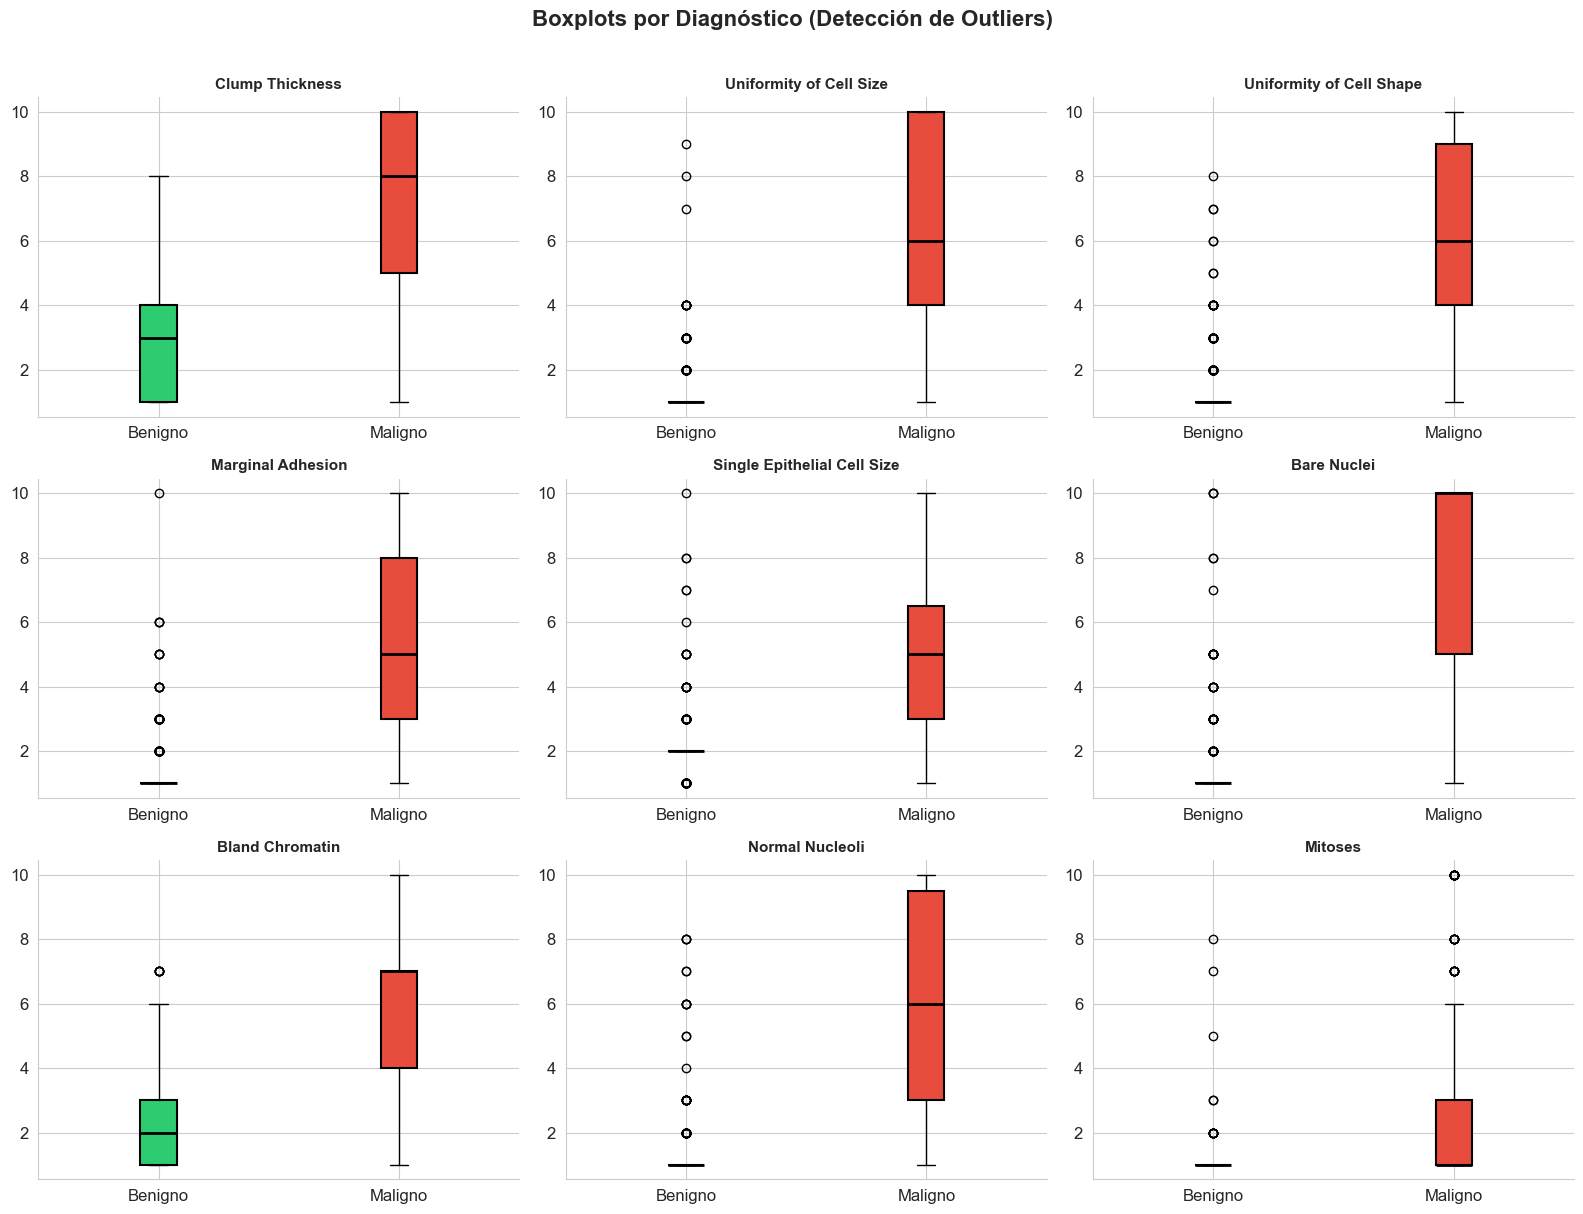


CONTEO DE OUTLIERS POR VARIABLE (Método IQR)
Mitoses                         120 outliers (17.6%)
Normal Nucleoli                  75 outliers (11.0%)
Marginal Adhesion                59 outliers (8.6%)
Single Epithelial Cell Size      54 outliers (7.9%)
Bland Chromatin                  20 outliers (2.9%)


In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

outlier_counts = {}
for i, col in enumerate(feat_cols):
    ax = axes[i]
    data = [df[df['Diagnostico']=='Benigno'][col], df[df['Diagnostico']=='Maligno'][col]]
    bp = ax.boxplot(data, tick_labels=['Benigno','Maligno'], patch_artist=True,
                    boxprops=dict(linewidth=1.5), medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(colors['Benigno'])
    bp['boxes'][1].set_facecolor(colors['Maligno'])
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    
    #Calc outliers con IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_counts[col] = n_outliers

fig.suptitle('Boxplots por Diagnóstico (Detección de Outliers)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("CONTEO DE OUTLIERS POR VARIABLE (Método IQR)")
print("="*50)
for col, count in sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True):
    if count > 0:
        pct = count/len(df)*100
        print(f"{col:30s} {count:4d} outliers ({pct:.1f}%)")

**Interpretación:** Las variables con mayor cantidad de outliers son Mitoses (120, 17.6%), Normal Nucleoli (75, 11.0%) y Marginal Adhesion (59, 8.6%). Estos outliers corresponden predominantemente a casos malignos con valores extremos. Es relevante. Es clínicamente consistente según nuestra investigación: tumores agresivos presentan mitosis más frecuentes y nucleólos anormales. Decidimos que **no eliminaremos estos outliers**, ya que representan información clínica importante que el modelo debe aprender a clasificar

## 7. Comparación: Media por Diagnóstico

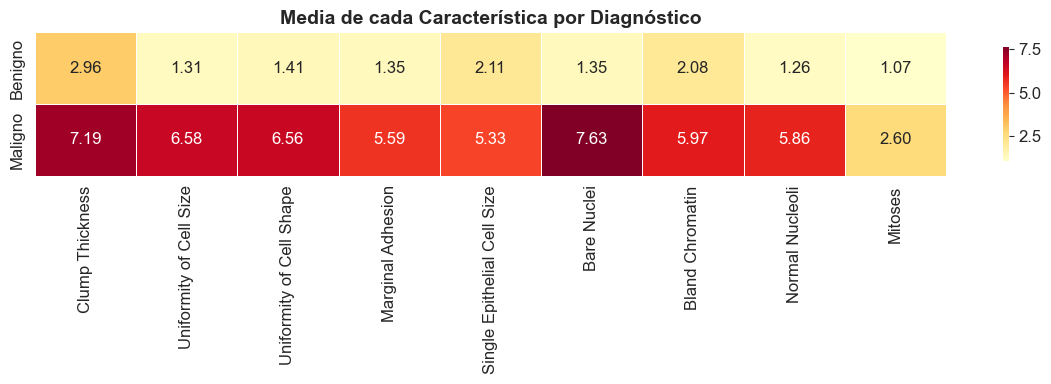


DIFERENCIA DE MEDIAS (Maligno - Benigno)
Bare Nuclei                     Δ = +6.28
Uniformity of Cell Size         Δ = +5.27
Uniformity of Cell Shape        Δ = +5.15
Normal Nucleoli                 Δ = +4.60
Marginal Adhesion               Δ = +4.24
Clump Thickness                 Δ = +4.22
Bland Chromatin                 Δ = +3.89
Single Epithelial Cell Size     Δ = +3.22
Mitoses                         Δ = +1.54


In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
means = df.groupby('Diagnostico')[feat_cols].mean()
sns.heatmap(means, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Media de cada Característica por Diagnóstico', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

#diferencia de medias
print("\n" + "="*60)
print("DIFERENCIA DE MEDIAS (Maligno - Benigno)")
print("="*60)
diff = means.loc['Maligno'] - means.loc['Benigno']
for col, val in diff.sort_values(ascending=False).items():
    print(f"{col:30s}  Δ = {val:+.2f}")

**Interpretación:** Las mayores diferencias de medias se encuentran en Bare Nuclei, Uniformity of Cell Size y Uniformity of Cell Shape. Esto confirma que estas 3 variables son los indicadores más fuertes (de malignidad). Mitoses muestra la menor diferencia, consistente con su menor correlación con la variable objetivo.

## 8. Análisis de Separabilidad: Pairplot

Top 4 variables más correlacionadas: ['Bare Nuclei', 'Uniformity of Cell Shape', 'Uniformity of Cell Size', 'Bland Chromatin']


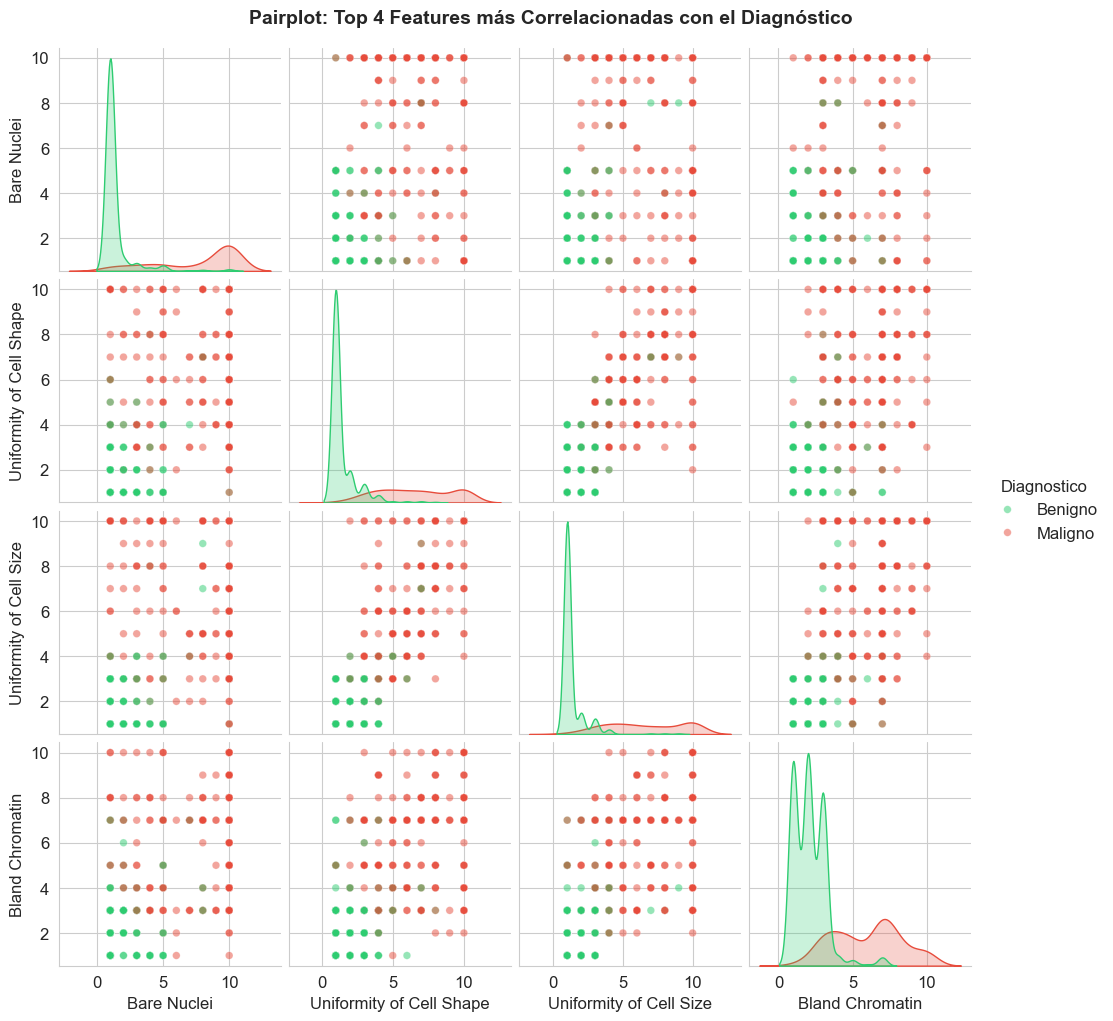

In [14]:
#features más correlacionadas
top4 = corr['Class'].drop('Class').abs().sort_values(ascending=False).head(4).index.tolist()
print(f"Top 4 variables más correlacionadas: {top4}")

g = sns.pairplot(df[top4 + ['Diagnostico']], hue='Diagnostico', palette=colors, 
                 diag_kind='kde', plot_kws={'alpha':0.5, 's':30, 'edgecolor':'white', 'linewidth':0.3})
g.figure.suptitle('Pairplot: Top 4 Features más Correlacionadas con el Diagnóstico', 
                   y=1.02, fontsize=14, fontweight='bold')
plt.show()

**Interpretación:** El pairplot confirma la buena separabilidad entre clases. Los tumores benignos (verde) se agrupan claramente en la esquina inferior izquierda (valores bajos), mientras que los malignos (rojo) se dispersan hacia valores altos. La combinación de Bare Nuclei con cualquiera de las variables de uniformidad genera límites de decisión visualmente claros, lo que sugiere que modelos de clasificación deberían alcanzar un rendimiento alto.

## 9. Conclusiones del EDA

### Hallazgos Principales:
1. **Problema identificado:** Clasificación binaria supervisada para detección de cáncer de mama (benigno vs maligno)
2. **Dataset limpio:** No hay valores nulos ni tipos de datos inconsistentes
3. **Desbalance moderado:** 65% benigno vs 35% maligno (ratio 1.86:1)
4. **Variables más discriminativas:** Bare Nuclei, Uniformity of Cell Shape y Uniformity of Cell Size (r > 0.82)
5. **Multicolinealidad detectada:** Cell Size y Cell Shape (r=0.91); considerar regularización
6. **Outliers clínicamente relevantes:** No eliminar; representan casos malignos agresivos

### Hipótesis para las Siguientes Semanas:
- **H1:** Bare Nuclei, Uniformity of Cell Size/Shape serán las features más importantes
- **H2:** Modelos basados en árboles capturarán mejor las relaciones no lineales
- **H3:** El Recall de la clase maligna debe priorizarse (minimizar falsos negativos)
- **H4:** La regularización será necesaria en modelos lineales por la multicolinealidad
- **H5:** Los outliers deben mantenerse como información clínica valiosa

## 10. Preprocesamiento: Limpieza y Validación del Dataset

En esta sección se valida el dataset original y se aplica una limpieza reproducible para dejar una versión lista para modelado.

In [2]:
# 10.1 Carga, diagnóstico de calidad y limpieza
raw = pd.read_csv('Datos.csv')
raw.columns = raw.columns.str.strip()

print('='*70)
print('1) DIMENSIÓN REAL DEL DATASET ORIGINAL')
print('='*70)
print(f'Filas: {raw.shape[0]} | Columnas: {raw.shape[1]}')

# Columnas esperadas en este dataset (Wisconsin original)
id_col = 'Sample code number'
target_col = 'Class'
feature_cols = [c for c in raw.columns if c not in [id_col, target_col]]

print('\n' + '='*70)
print('2) DISTRIBUCIÓN REAL DE LA VARIABLE CLASS')
print('='*70)
class_counts_raw = raw[target_col].value_counts(dropna=False).sort_index()
class_pct_raw = (class_counts_raw / len(raw) * 100).round(2)
class_table_raw = pd.DataFrame({'conteo': class_counts_raw, 'porcentaje': class_pct_raw})
print(class_table_raw)
print(f"\nSuma de conteos por clase: {int(class_counts_raw.sum())}")
print(f"Total de registros: {len(raw)}")
print(f"¿Coinciden? {'Sí' if int(class_counts_raw.sum()) == len(raw) else 'No'}")

print('\n' + '='*70)
print('3) TIPOS DE DATOS ORIGINALES')
print('='*70)
print(raw.dtypes)

# Estandarizar posibles marcadores inválidos antes de conversión numérica
clean = raw.copy()
clean = clean.replace(['?', ' ?', '? ', 'NA', 'N/A', 'na', 'n/a', ''], np.nan)

# Convertir a numérico columnas clave
for col in [id_col, target_col] + feature_cols:
    clean[col] = pd.to_numeric(clean[col], errors='coerce')

print('\n' + '='*70)
print('4) VALORES FALTANTES / INVÁLIDOS (POST-CONVERSIÓN NUMÉRICA)')
print('='*70)
missing_counts = clean.isna().sum().sort_values(ascending=False)
print(missing_counts[missing_counts > 0] if (missing_counts > 0).any() else 'No se detectaron faltantes.')

# Reglas de validez
invalid_feature_mask = pd.Series(False, index=clean.index)
for col in feature_cols:
    invalid_feature_mask |= clean[col].notna() & ~clean[col].between(1, 10)

invalid_class_mask = clean[target_col].notna() & ~clean[target_col].isin([2, 4])

print('\n' + '='*70)
print('5) REGISTROS EXTRAÑOS / FUERA DE RANGO')
print('='*70)
print(f'Registros con alguna feature fuera de [1,10]: {int(invalid_feature_mask.sum())}')
print(f'Registros con Class inválida (distinta de 2 o 4): {int(invalid_class_mask.sum())}')

print('\n' + '='*70)
print('6) DUPLICADOS')
print('='*70)
row_dups = int(clean.duplicated().sum())
id_dups = int(clean[id_col].duplicated().sum())
print(f'Duplicados de fila completa: {row_dups}')
print(f'Duplicados de Sample code number: {id_dups}')

# Máscaras de limpieza
missing_any_mask = clean[[target_col] + feature_cols].isna().any(axis=1)
invalid_any_mask = invalid_feature_mask | invalid_class_mask
duplicate_row_mask = clean.duplicated(keep='first')

# Dataset limpio para modelado
clean_model = clean.loc[~missing_any_mask & ~invalid_any_mask & ~duplicate_row_mask].copy()

print('\n' + '='*70)
print('7) RESULTADO DE LIMPIEZA')
print('='*70)
print(f'Total original: {len(clean)}')
print(f'Removidos por faltantes/inválidos: {int((missing_any_mask | invalid_any_mask).sum())}')
print(f'Removidos por duplicado de fila: {int(duplicate_row_mask.sum())}')
print(f'Total limpio final: {len(clean_model)}')

# Validación final de clase en dataset limpio
print('\nDistribución final de Class (dataset limpio):')
class_counts_clean = clean_model[target_col].value_counts().sort_index()
class_pct_clean = (class_counts_clean / len(clean_model) * 100).round(2)
print(pd.DataFrame({'conteo': class_counts_clean, 'porcentaje': class_pct_clean}))

# Identificador para modelado
print('\n' + '='*70)
print('8) TRATAMIENTO DE Sample code number')
print('='*70)
print('Se conserva en la versión limpia para trazabilidad, pero se excluye del modelado por ser identificador.')

# Exportables
clean_with_id = clean_model.copy()
clean_no_id = clean_model.drop(columns=[id_col])

clean_with_id.to_csv('Datos_limpio.csv', index=False)
clean_no_id.to_csv('Datos_modelado.csv', index=False)

print('\nArchivos generados:')
print('- Datos_limpio.csv (incluye identificador para trazabilidad)')
print('- Datos_modelado.csv (sin Sample code number, listo para modelar)')

1) DIMENSIÓN REAL DEL DATASET ORIGINAL
Filas: 683 | Columnas: 11

2) DISTRIBUCIÓN REAL DE LA VARIABLE CLASS
       conteo  porcentaje
Class                    
2         444       65.01
4         239       34.99

Suma de conteos por clase: 683
Total de registros: 683
¿Coinciden? Sí

3) TIPOS DE DATOS ORIGINALES
Sample code number             int64
Clump Thickness                int64
Uniformity of Cell Size        int64
Uniformity of Cell Shape       int64
Marginal Adhesion              int64
Single Epithelial Cell Size    int64
Bare Nuclei                    int64
Bland Chromatin                int64
Normal Nucleoli                int64
Mitoses                        int64
Class                          int64
dtype: object

4) VALORES FALTANTES / INVÁLIDOS (POST-CONVERSIÓN NUMÉRICA)
No se detectaron faltantes.

5) REGISTROS EXTRAÑOS / FUERA DE RANGO
Registros con alguna feature fuera de [1,10]: 0
Registros con Class inválida (distinta de 2 o 4): 0

6) DUPLICADOS
Duplicados de fila com

## 10.2 Resumen de problemas encontrados y resolución

- **Inconsistencia detectada con Semana 1:** el reporte mencionaba 682 registros, pero el archivo actual `Datos.csv` contiene **683 filas y 11 columnas**.
- **Distribución real de `Class` en crudo:**
  - Clase 2 (Benigno): **444** (65.01%)
  - Clase 4 (Maligno): **239** (34.99%)
  - La suma por clase (**683**) sí coincide con el total actual del archivo.
- **Tipos de datos:** todas las columnas quedaron en formato numérico (`int64`) tras validación.
- **Faltantes/ inválidos:** no se detectaron nulos, marcadores inválidos (`?`, `NA`, etc.) ni valores fuera de rango en features (esperado 1 a 10).
- **Duplicados:**
  - Se detectaron **8 filas completamente duplicadas** y se eliminaron.
  - Se detectaron **53 repeticiones en `Sample code number`**, pero no se eliminaron por sí solas porque no implican necesariamente filas idénticas.
- **`Sample code number` para modelado:**
  - Se considera **identificador** y se excluye del dataset para entrenamiento.
  - Se conserva solo en una versión de trazabilidad.

### Resultado final

- **`Datos_limpio.csv`**: dataset limpio con identificador (trazabilidad), **675 filas**.
- **`Datos_modelado.csv`**: dataset limpio sin `Sample code number`, **listo para modelar**.

## 11. Semana 2: Seleccion de Variables y Particion de Datos

### Alcance de esta seccion
- Definir `X` y `y` para modelado.
- Definir dos escenarios de variables: baseline completo y subconjunto top.
- Hacer `train/test split` estratificado y reproducible.
- Verificar distribucion de clases en train y test.
- Dejar listas las matrices para Personas 3 y 4.



In [2]:
%pip install pandas scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.7 MB 8.1 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.7 MB 10.8 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.7 MB 13.7 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 12.0 MB/s  0:00:00
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   -------------- ------------------------- 4.5/12.3 MB 22.2 MB/s eta 0:00:01
   ----------------------------- ---------- 9.2/12.3 MB 23.3 MB/s eta 0:00:01
   -

In [3]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# cargar dataset listo para modelado sin asumir cwd
candidatos = [
    Path('data/Datos_modelado.csv'),
    Path('../data/Datos_modelado.csv'),
    Path('Datos_modelado.csv')
]
ruta_modelado = next((p for p in candidatos if p.exists()), None)
if ruta_modelado is None:
    raise FileNotFoundError('no se encontro Datos_modelado.csv en rutas esperadas')

model_df = pd.read_csv(ruta_modelado)
model_df.columns = model_df.columns.str.strip()

print(f'archivo usado: {ruta_modelado.as_posix()}')
print(f'dimensiones: {model_df.shape[0]} filas x {model_df.shape[1]} columnas')
print('\ncolumnas disponibles:')
print(model_df.columns.tolist())

archivo usado: ../data/Datos_modelado.csv
dimensiones: 675 filas x 10 columnas

columnas disponibles:
['Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses', 'Class']


In [4]:
# definir target y escenarios de variables
objetivo = 'Class'
if objetivo not in model_df.columns:
    raise ValueError('no existe la columna Class en el dataset de modelado')

features_all = [c for c in model_df.columns if c != objetivo]
features_top = [
    'Bare Nuclei',
    'Uniformity of Cell Size',
    'Uniformity of Cell Shape'
]

faltantes_top = [c for c in features_top if c not in model_df.columns]
if faltantes_top:
    raise ValueError(f'faltan columnas del subconjunto top: {faltantes_top}')

X_all = model_df[features_all].copy()
X_top = model_df[features_top].copy()
y = model_df[objetivo].copy()

print('escenario A (todas las variables):')
print(f'features: {len(features_all)} -> {features_all}')
print('\nescenario B (subconjunto top):')
print(f'features: {len(features_top)} -> {features_top}')

print('\ndistribucion base de class:')
dist_base = y.value_counts().sort_index().to_frame('conteo')
dist_base['porcentaje'] = (dist_base['conteo'] / len(y) * 100).round(2)
print(dist_base)

escenario A (todas las variables):
features: 9 -> ['Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses']

escenario B (subconjunto top):
features: 3 -> ['Bare Nuclei', 'Uniformity of Cell Size', 'Uniformity of Cell Shape']

distribucion base de class:
       conteo  porcentaje
Class                    
2         439       65.04
4         236       34.96


In [5]:
# split estratificado y reproducible (acordado: 80/20)
RANDOM_STATE = 42
TEST_SIZE = 0.20

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# mantener el mismo split para el escenario top usando los mismos indices
X_train_top = X_top.loc[X_train_all.index].copy()
X_test_top = X_top.loc[X_test_all.index].copy()

print('split completado')
print(f'random_state={RANDOM_STATE}, test_size={TEST_SIZE}, estratificado=True')
print(f'X_train_all: {X_train_all.shape}')
print(f'X_test_all: {X_test_all.shape}')
print(f'X_train_top: {X_train_top.shape}')
print(f'X_test_top: {X_test_top.shape}')
print(f'y_train: {y_train.shape}, y_test: {y_test.shape}')

split completado
random_state=42, test_size=0.2, estratificado=True
X_train_all: (540, 9)
X_test_all: (135, 9)
X_train_top: (540, 3)
X_test_top: (135, 3)
y_train: (540,), y_test: (135,)


In [7]:
# verificacion de proporcion de clases en total, train y test

def tabla_distribucion_clase(y_total, y_train, y_test):
    base = pd.DataFrame({
        'total_conteo': y_total.value_counts().sort_index(),
        'train_conteo': y_train.value_counts().sort_index(),
        'test_conteo': y_test.value_counts().sort_index()
    }).fillna(0).astype(int)

    base['total_pct'] = (base['total_conteo'] / len(y_total) * 100).round(2)
    base['train_pct'] = (base['train_conteo'] / len(y_train) * 100).round(2)
    base['test_pct'] = (base['test_conteo'] / len(y_test) * 100).round(2)

    return base

dist_split = tabla_distribucion_clase(y, y_train, y_test)
print('distribucion de clase (2=benigno, 4=maligno):')
print(dist_split)

print('\ncontrol rapido de diferencia de porcentajes vs total:')
print((dist_split[['train_pct', 'test_pct']].sub(dist_split['total_pct'], axis=0)).round(2))

distribucion de clase (2=benigno, 4=maligno):
       total_conteo  train_conteo  test_conteo  total_pct  train_pct  test_pct
Class                                                                         
2               439           351           88      65.04       65.0     65.19
4               236           189           47      34.96       35.0     34.81

control rapido de diferencia de porcentajes vs total:
       train_pct  test_pct
Class                     
2          -0.04      0.15
4           0.04     -0.15


### 11.1 Justificacion tecnica 

- Se definen dos escenarios de variables para apoyar la comparacion de modelos base en Semana 2:
  - **Escenario A (baseline completo):** todas las variables del dataset modelado.
  - **Escenario B (subconjunto top):** `Bare Nuclei`, `Uniformity of Cell Size` y `Uniformity of Cell Shape`, por su alta capacidad discriminativa observada en Semana 1.
- Se mantiene la pareja `Uniformity of Cell Size` y `Uniformity of Cell Shape` en el baseline, documentando su multicolinealidad alta como riesgo potencial para modelos lineales.
- Se usa `train/test split` **80/20 estratificado** para conservar la proporcion benigno/maligno y asegurar comparabilidad entre modelos.
- Se fija `random_state = 42` para garantizar reproducibilidad del experimento.

In [8]:
# handoff para personas 3 y 4
print('variables listas para entrenamiento:')
print('- escenario A: X_train_all, X_test_all, y_train, y_test')
print('- escenario B: X_train_top, X_test_top, y_train, y_test')

resumen_handoff = pd.DataFrame([
    ['A_all', X_train_all.shape, X_test_all.shape, y_train.shape, y_test.shape, len(features_all)],
    ['B_top3', X_train_top.shape, X_test_top.shape, y_train.shape, y_test.shape, len(features_top)]
], columns=['escenario', 'X_train_shape', 'X_test_shape', 'y_train_shape', 'y_test_shape', 'n_features'])

print('\nresumen de handoff:')
print(resumen_handoff)

print('\ncolumnas escenario A:')
print(features_all)
print('\ncolumnas escenario B:')
print(features_top)

variables listas para entrenamiento:
- escenario A: X_train_all, X_test_all, y_train, y_test
- escenario B: X_train_top, X_test_top, y_train, y_test

resumen de handoff:
  escenario X_train_shape X_test_shape y_train_shape y_test_shape  n_features
0     A_all      (540, 9)     (135, 9)        (540,)       (135,)           9
1    B_top3      (540, 3)     (135, 3)        (540,)       (135,)           3

columnas escenario A:
['Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses']

columnas escenario B:
['Bare Nuclei', 'Uniformity of Cell Size', 'Uniformity of Cell Shape']
